# 02 · Feature engineering as a research gate

**Question:** Which representations improve rule-conditioned transfer, and is the evidence strong enough to finish feature engineering?

**Gate: OPEN.** Broad generation, screening and controlled experiments have executed. Independent confirmation of the selected feature representation has not. The research keeps the original lexical reference and does not trigger final retraining.

In [1]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
from jigsaw_rules.review import public_evidence
from jigsaw_rules.runtime import environment

root = Path(os.environ.get("JIGSAW_ROOT", Path.cwd())).resolve()
if root.name == "notebooks":
    root = root.parent
baseline = public_evidence(root, "baseline")
semantic = public_evidence(root, "semantic")
assert baseline["training_sha256"] == semantic["training_sha256"]
print("Completed feature experiments | 2,029 rows | two labeled rules")
print("Aggregate checksums verified. This notebook performs no model fitting.")
protocols = {"seen_rule": "Familiar rules", "heldout_rule": "Held-out rule"}

def metric_table(records, heldout=False):
    return pd.DataFrame([{"Representation": r["model"], "Validation": protocols[r["protocol"]],
        "Rule macro AUC": r["metrics"]["rule_macro_auc"],
        "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"],
        "Average precision": r["metrics"]["average_precision"]}
        for r in records if not heldout or r["protocol"] == "heldout_rule"]).round(4)


Completed feature experiments | 2,029 rows | two labeled rules
Aggregate checksums verified. This notebook performs no model fitting.


In [2]:
import sys
sys.path.insert(0, str(root / "scripts"))
from build_research_report import display_figure
from build_release_report import display_boundary
from jigsaw_rules.features import feature_evidence
from jigsaw_rules.research import research_evidence
from jigsaw_rules.diagnostics import diagnostic_evidence
from jigsaw_rules.pairs import pairs_evidence
from jigsaw_rules.robustness import robustness_evidence
from jigsaw_rules.gate import feature_gate
from jigsaw_rules.instructions import instruction_evidence
from jigsaw_rules.released import released_evidence

controls = feature_evidence(root)
research = research_evidence(root)
sensitivity = diagnostic_evidence(root)
pairs = pairs_evidence(root)
robustness = robustness_evidence(root)
assert all(item is not None for item in (controls, research, sensitivity, pairs, robustness))
gate = feature_gate(root)
instructions = instruction_evidence(root)
released = released_evidence(root)
assert released is not None
print("Verified research runs:", gate["studies"])


Verified research runs: {'research': '9ec008d506b0bc64a717', 'sensitivity': 'bce07fd60bc7543fca49', 'pairs': '537cf2213c813b8ebd4b', 'robustness': 'a09455ec14e9b3d6ab61', 'instructions': '96bf69f42f9063e01a12'}


## 1 · Establish the reference
Comment-only TF-IDF measures lexical transfer. The rule/example reference adds similarities to the rule and supplied examples. The early four-candidate study isolated rule text, support contrasts, structure and their combination. These are historical, preserved experiments.

In [3]:
display(metric_table(baseline["results"], heldout=True))
display(metric_table(controls["results"], heldout=True))

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,comment_only,Held-out rule,0.6041,0.6731,0.2400,0.6108
1,rule_examples,Held-out rule,0.6156,0.6736,0.2405,0.6241


,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,rule_text,Held-out rule,0.6228,0.6939,0.2433,0.6451
1,support_contrast,Held-out rule,0.5768,0.8201,0.2873,0.5802
2,structure,Held-out rule,0.4625,0.7496,0.2745,0.5089
3,combined,Held-out rule,0.5373,0.8853,0.3047,0.5358


## 2 · Search broadly, with a rationale
The broad bank contains word and character ngrams; 1,512 structural/context interactions; 207 lexical similarity transformations; support-conditioned token products; 6,144 frozen embedding coordinates/interactions; 32 semantic geometry summaries; 207 training-relative ranks; community indicators; and nine nested target/frequency/novelty candidates.

The separate joint-text probe adds 99 entailment/contradiction/neutral transformations from frozen DeBERTa. Support summaries are invariant to swapping the two positive or two negative examples. Every family has provenance, availability and leakage notes in the [feature catalog](../docs/FEATURE_RESEARCH.md). Counts below are **per-fold candidate columns**, not a sum over repeated CV fits.

Per-fold screened bank totals, including each joint-text family once:


candidates  retained  rejected
protocol     fold                                
heldout_rule 0         104800      7975     96825
             1         103537      6480     97057
seen_rule    0          89059      4919     84140
             1          94651      5541     89110
             2          96271      5419     90852

candidates        retained      
                       min    max      min   max
family                                          
character            39426  60000     3710  4096
community               63     93       23    59
lexical                207    207       64    64
ranks                  207    207       64    64
semantic              6144   6144      256   256
semantic_scalar         32     32       31    31
structure             1512   1512      128   128
support_tokens       16558  28523       85   240
target_context           9      9        4     8
word                 16558  28523      489  2988

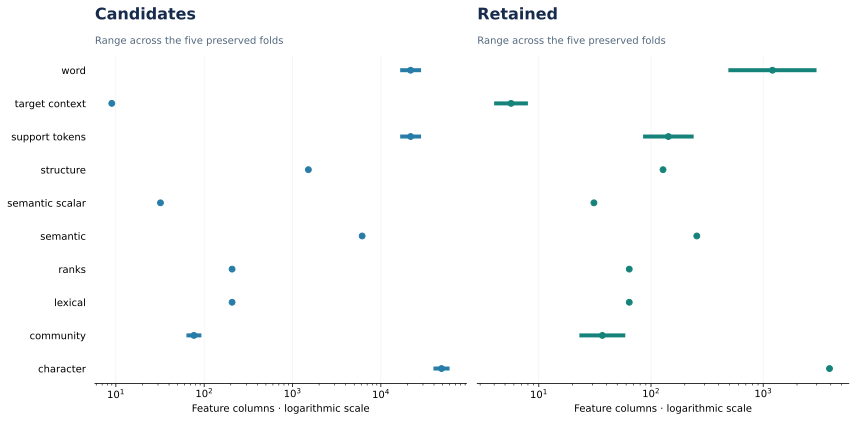

In [4]:
screen = pd.DataFrame(research["screening"]["folds"])
counts = screen.groupby(["protocol", "fold"])[["candidates", "retained", "rejected"]].sum()
joint_counts = pd.DataFrame(pairs["screening"])
combined_counts = counts + joint_counts[joint_counts.model == "all_nli"].set_index(["protocol", "fold"])[["candidates", "retained", "rejected"]]
if instructions is not None:
    instruction_counts = pd.DataFrame(instructions["screening"])
    combined_counts += instruction_counts[instruction_counts.model == "instruction_features"].set_index(["protocol", "fold"])[["candidates", "retained", "rejected"]]
print("Per-fold screened bank totals, including each joint-text family once:")
display(combined_counts)
display(screen.groupby("family")[["candidates", "retained"]].agg(["min", "max"]))
display_figure(root, "screening")

## 3 · Screen inside training boundaries
The screen rejects nonfinite/schema errors, constant or nearly constant columns, features seen in fewer than three training rows, exact duplicates and suspicious perfect separators. Training-label effect scores impose fixed budgets. Dense redundancy screening checks |correlation| ≥0.995 within the strongest budgeted pool; sparse duplicates use column hashes to avoid a quadratic comparison of vocabulary columns.

No outer validation statistic participates. Detailed per-feature decisions and selected column hashes are private reproducibility artifacts. Unscreened controls below test whether the screen itself discarded useful lexical signal.

In [5]:
decisions = pd.DataFrame([{"Family": r["family"], "Reason": reason, "Columns": count} for r in research["screening"]["folds"] for reason, count in r["decisions"].items()])
display(decisions.groupby("Reason").Columns.sum().to_frame("Column decisions across five folds"))
assert (screen.candidates == screen.retained + screen.rejected).all()
assert screen.missing_or_nonfinite.sum() == 0

,Column decisions across five folds
Reason,
constant_or_near_constant,199621
exact_duplicate,17689
high_training_correlation,451
rare,193487
retained,30042
screen_budget,46353


## 4 · Separate feature effects from model tuning
Twenty-one broad configurations run on the same five saved folds: 105 fits. A fixed logistic classifier (C=2, liblinear, seed 2025) measures additions to the same screened-word control, family-only controls and leave-one-family-out ablations. No hyperparameter sweep is used. Scaling and fixed per-family budgets are part of the tested representation.

Intervals use 1,000 paired normalized-comment-group bootstrap draws. The wide intervals adjust simultaneously for the study's planned contrasts. They condition on fixed OOF predictions and two rules; they do not correct for repeated research across studies or establish performance on arbitrary unseen policies.

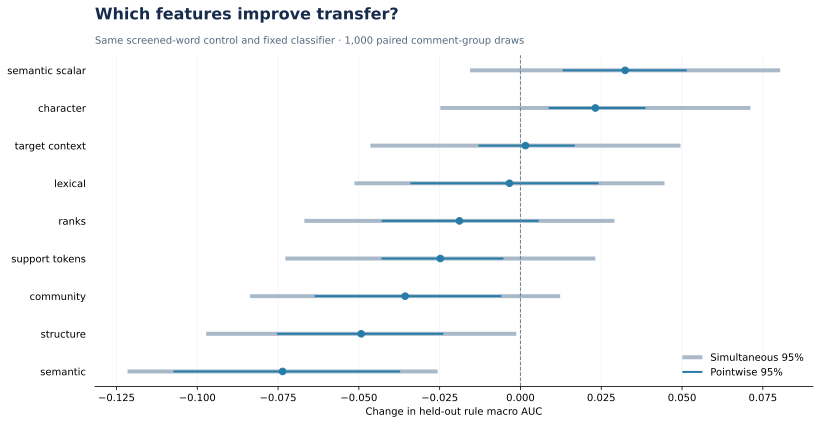

,contrast,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
57,add_character,0.0232,0.0087,0.0387,-0.0248,0.0712
58,add_structure,-0.0493,-0.0753,-0.0239,-0.0973,-0.0013
59,add_lexical,-0.0034,-0.0341,0.0242,-0.0514,0.0446
60,add_support_tokens,-0.0248,-0.0430,-0.0052,-0.0728,0.0232
61,add_semantic,-0.0736,-0.1074,-0.0372,-0.1216,-0.0256
62,add_semantic_scalar,0.0324,0.0131,0.0515,-0.0156,0.0804
63,add_ranks,-0.0189,-0.0430,0.0057,-0.0669,0.0291
64,add_community,-0.0357,-0.0637,-0.0059,-0.0837,0.0123
65,add_target_context,0.0016,-0.0130,0.0168,-0.0464,0.0495


In [6]:
display_figure(root, "ablation")
effects = pd.DataFrame(research["uncertainty"])
held_effects = effects[effects.protocol == "heldout_rule"]
display(held_effects.loc[held_effects.contrast.str.startswith("add_"), ["contrast", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))

## 5 · Keep the negative findings visible
Character ngrams and compact semantic geometry improve the matched screened-word control at pointwise confidence, but their simultaneous intervals include zero. Raw embedding coordinates and the structural expansion hurt transfer. Community and nested target encodings do not establish robust gains. The all-family representation is substantially worse than the historical reference. More features are not automatically better.

In [7]:
display(metric_table(research["results"], heldout=True).sort_values("Rule macro AUC", ascending=False))
display(held_effects.loc[held_effects.contrast.str.startswith("remove_"), ["contrast", "observed_delta", "simultaneous_lower", "simultaneous_upper"]].round(4))

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
6,word_semantic_scalar,Held-out rule,0.6217,0.7248,0.2604,0.6010
1,word_character,Held-out rule,0.6125,0.6867,0.2448,0.6118
16,without_structure,Held-out rule,0.6062,1.0259,0.2876,0.5881
10,semantic_scalar_only,Held-out rule,0.6020,0.8488,0.3051,0.5500
9,word_target_context,Held-out rule,0.5909,0.7001,0.2511,0.5919
0,word_screened,Held-out rule,0.5893,0.6782,0.2421,0.5993
3,word_lexical,Held-out rule,0.5859,1.0831,0.2821,0.5726
17,without_lexical,Held-out rule,0.5767,0.9096,0.3035,0.5574
7,word_ranks,Held-out rule,0.5705,0.7062,0.2535,0.6039
20,without_ranks,Held-out rule,0.5669,1.3132,0.3299,0.5181


,contrast,observed_delta,simultaneous_lower,simultaneous_upper
66,remove_character,0.0113,-0.0367,0.0593
67,remove_structure,-0.0519,-0.0998,-0.0039
68,remove_lexical,-0.0224,-0.0704,0.0256
69,remove_support_tokens,0.0209,-0.0270,0.0689
70,remove_semantic_scalar,0.0179,-0.0300,0.0659
71,remove_ranks,-0.0126,-0.0605,0.0354


## 6 · Attribute performance and inspect stability
Whole-family permutation within each validation rule measures dependence while avoiding impossible cross-rule shuffles. Repeated permutations and coefficient summaries are descriptive; correlated families can substitute for one another. Retained-name Jaccard measures selection stability separately from predictive usefulness. Raw token identities are excluded from public output.

SHAP is not added merely as decoration: these fixed linear probes already expose coefficients, matched ablations and group permutation. Those diagnostics directly answer the current feature questions without another correlated attribution summary.

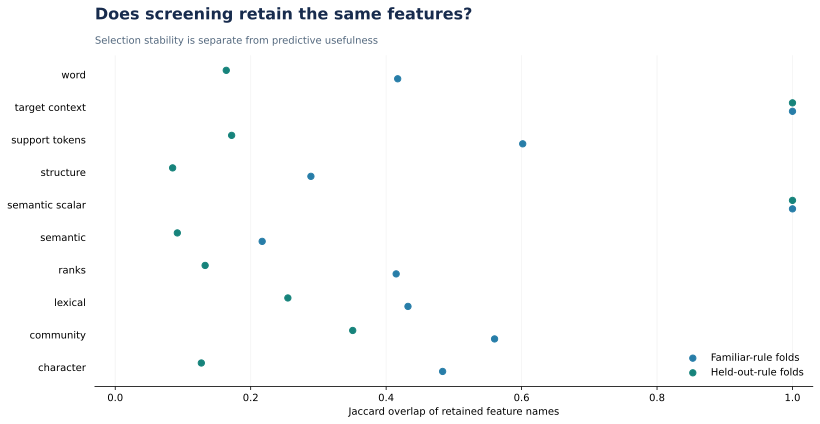

,mean_auc_drop,minimum_fold_drop,maximum_fold_drop,mean_absolute_logit
family,,,,
character,0.0064,0.0004,0.0124,0.3437
lexical,0.0100,0.0092,0.0108,1.2686
ranks,0.0032,0.0030,0.0034,0.3447
semantic_scalar,0.0224,0.0189,0.0259,0.6512
structure,0.0120,-0.0054,0.0293,0.9355
support_tokens,-0.0011,-0.0040,0.0019,0.3185
word,0.0035,0.0024,0.0046,0.2686


In [8]:
display_figure(root, "stability")
permutation = pd.DataFrame(research["importance"])
permutation["mean_permutation_drop"] = permutation.within_rule_permutation_auc_drops.map(lambda values: sum(values) / len(values))
selected_importance = permutation[(permutation.protocol == "heldout_rule") & (permutation.model == "all_transfer")]
display(selected_importance.groupby("family").agg(mean_auc_drop=("mean_permutation_drop", "mean"), minimum_fold_drop=("mean_permutation_drop", "min"), maximum_fold_drop=("mean_permutation_drop", "max"), mean_absolute_logit=("mean_absolute_logit_contribution", "mean")).round(4))

## 7 · Challenge the selection and representation choices
Fifty-five additional fits compare full word/character vocabularies, training-only NB log-count weighting, and five 128-component SVD representations fitted only on outer training rows. None of the low-rank alternatives improves the original reference. Label-free lexical support scores and seven frozen Qwen geometry scores isolate aggregation effects. The normalized positive/negative centroid margin is the strongest observed geometry alternative; its uncertainty still matters. Self-support exclusion preserves the main ranking advantage, but does not create new policies.

In [9]:
display(metric_table(sensitivity["results"], heldout=True).sort_values("Rule macro AUC", ascending=False))
intervals = pd.DataFrame(sensitivity["uncertainty"])
display(intervals.loc[(intervals.protocol == "heldout_rule") & intervals.contrast.isin(["qwen_centroid", "character_full", "reweight_word", "reweight_character"]), ["contrast", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))
selected = ["original_reference", "qwen_centroid", "qwen_maximum", "word_semantic_scalar"]
rows = [r for r in sensitivity["sensitivity"] if r["protocol"] == "heldout_rule" and r["model"] in selected]
display(metric_table(rows, heldout=True))

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
9,qwen_centroid,Held-out rule,0.6416,0.6693,0.2385,0.6228
14,qwen_maximum,Held-out rule,0.6351,0.6786,0.2423,0.6217
10,qwen_kernel_0.05,Held-out rule,0.6347,0.7639,0.2659,0.6186
11,qwen_kernel_0.1,Held-out rule,0.6333,0.6768,0.2420,0.6150
12,qwen_kernel_0.2,Held-out rule,0.6316,0.6697,0.2388,0.6104
13,qwen_kernel_0.5,Held-out rule,0.6300,0.6802,0.2436,0.6066
15,qwen_mean,Held-out rule,0.6286,0.6817,0.2440,0.6031
0,character_full,Held-out rule,0.6235,0.6646,0.2361,0.6200
16,word_character_full,Held-out rule,0.6195,0.6680,0.2375,0.6204
2,character_support_max,Held-out rule,0.6097,0.6724,0.2395,0.6138


,contrast,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
25,character_full,0.0080,-0.0130,0.0310,-0.0365,0.0524
34,qwen_centroid,0.0260,-0.0056,0.0578,-0.0184,0.0705
47,reweight_word,0.0024,-0.0148,0.0188,-0.0420,0.0469
48,reweight_character,-0.0334,-0.0532,-0.0155,-0.0779,0.0110


,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,original_reference,Held-out rule,0.6095,0.6775,0.2421,0.6130
1,qwen_centroid,Held-out rule,0.6361,0.6743,0.2405,0.6119
2,qwen_maximum,Held-out rule,0.6294,0.6843,0.2445,0.6110
3,word_semantic_scalar,Held-out rule,0.6157,0.7312,0.2627,0.5890


## 8 · Joint text encoding without model fine-tuning
The pinned `cross-encoder/nli-deberta-v3-small` model jointly reads the comment with (a) a fixed violation hypothesis, (b) a compliance hypothesis, or (c) each supplied example. The encoder stays frozen. Rule-only, support-only, combined, word-plus-NLI and broad-plus-NLI probes use the same fixed classifier and folds: 25 fits. A fixed zero-shot rule margin is reported separately.

Weights are trained on general NLI, not moderation judgments. Entailment is a feature hypothesis, not an assertion that NLI understands every policy. Inference batches have immutable hashes, truncation diagnostics, verified completion markers and S3 checkpoints.

In [10]:
display(metric_table(pairs["results"], heldout=True).sort_values("Rule macro AUC", ascending=False))
ni = pd.DataFrame(pairs["uncertainty"])
display(ni.loc[ni.protocol == "heldout_rule", ["contrast", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))
display(pd.Series({k: v for k, v in pairs["inference"].items() if k != "contract"}, name="NLI inference"))
ns = pd.DataFrame(pairs["screening"])
display(ns.groupby("model")[["candidates", "retained"]].agg(["min", "max"]))

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
3,word_nli,Held-out rule,0.5964,0.6964,0.2475,0.6097
2,all_nli,Held-out rule,0.5602,0.7252,0.2631,0.5475
4,transfer_nli,Held-out rule,0.5517,1.3259,0.3422,0.5229
0,rule_nli,Held-out rule,0.5474,0.7257,0.2633,0.5327
5,rule_margin,Held-out rule,0.5317,0.6960,0.2512,0.5891
1,support_nli,Held-out rule,0.5220,1.1269,0.3033,0.4698


,contrast,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
8,rule_nli,-0.0682,-0.1062,-0.0283,-0.1162,-0.0202
9,support_nli,-0.0935,-0.1286,-0.0556,-0.1416,-0.0455
10,all_nli,-0.0554,-0.0923,-0.0168,-0.1034,-0.0073
11,word_nli,-0.0192,-0.0443,0.0075,-0.0672,0.0288
12,transfer_nli,-0.0638,-0.0961,-0.0292,-0.1119,-0.0158
13,rule_margin,-0.0839,-0.1228,-0.0468,-0.1319,-0.0359
14,add_nli_to_word,0.0070,-0.0134,0.0286,-0.0410,0.0551
15,add_nli_to_transfer,-0.0026,-0.0120,0.0074,-0.0506,0.0454


cache                         b8fef4f8c6bf3e0c473c
unique_pairs                                 11835
requested_pairs                              12174
original_inference_seconds             1658.648885
truncated_pairs                                 26
Name: NLI inference, dtype: object

candidates     retained    
                    min max      min max
model                                   
all_nli              99  99       32  32
rule_nli             27  27       24  26
support_nli          72  72       32  32
transfer_nli         99  99       32  32
word_nli             99  99       32  32

## 9 · Fixed instruction likelihoods
A separate frozen Qwen3-0.6B probe scores Yes/No token likelihoods under three fixed templates: rule only, examples only, and both. Thinking and generation are disabled. There is no competition-label fine-tuning or prompt sweep. Thirty-six probability, margin, answer-mass and context-difference candidates feed the same fixed classifier, with lexical and semantic additions. Support examples are sorted within their label groups. Field budgets preserve the question when text is long. The completed probe does not improve held-out-rule performance. These negative results apply to this fixed small model and its documented field budgets; they do not establish failure of every instruction model.

In [11]:
if instructions is None:
    print("The bounded instruction-feature experiment has no published results yet.")
else:
    display(metric_table(instructions["results"], heldout=True).sort_values("Rule macro AUC", ascending=False))
    ii = pd.DataFrame(instructions["uncertainty"])
    display(ii.loc[ii.protocol == "heldout_rule", ["contrast", "observed_delta", "ci_lower", "ci_upper", "simultaneous_lower", "simultaneous_upper"]].round(4))
    display(pd.Series({k: v for k, v in instructions["inference"].items() if k != "contract"}, name="Instruction inference"))

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
5,word_instruction,Held-out rule,0.5755,0.6958,0.2495,0.5850
4,semantic_instruction,Held-out rule,0.5716,0.7812,0.2869,0.5335
3,instruction_features,Held-out rule,0.4808,0.7760,0.2859,0.4716
2,frozen_support,Held-out rule,0.4753,0.7432,0.2708,0.4667
0,frozen_rule,Held-out rule,0.4504,0.8861,0.3301,0.4314
1,frozen_rule_support,Held-out rule,0.4488,0.8323,0.3081,0.4316


,contrast,observed_delta,ci_lower,ci_upper,simultaneous_lower,simultaneous_upper
9,frozen_rule,-0.1652,-0.2118,-0.1241,-0.2149,-0.1155
10,frozen_rule_support,-0.1667,-0.2075,-0.1265,-0.2164,-0.1171
11,frozen_support,-0.1403,-0.1765,-0.1023,-0.1899,-0.0906
12,instruction_features,-0.1347,-0.1734,-0.0976,-0.1844,-0.0851
13,semantic_instruction,-0.0440,-0.0808,-0.0095,-0.0936,0.0057
14,word_instruction,-0.0401,-0.0634,-0.0170,-0.0898,0.0096
15,add_support_to_rule_prompt,-0.0015,-0.0262,0.0233,-0.0512,0.0481
16,add_rule_to_support_prompt,-0.0265,-0.0550,0.0002,-0.0761,0.0232
17,instruction_vs_centroid,-0.0700,-0.0878,-0.0498,-0.1197,-0.0203


cache                     fc6d5435ff33843e3390
unique_prompts                            5933
requested_prompts                         6087
truncated_input_fields                    1759
summed_worker_seconds               7304.08126
Name: Instruction inference, dtype: object

## 10 · Completion is an evidence decision
Broad exploration is implemented and executed, but the best observed score is selected from many experiments on the same two rule types. The host release now supplies the next research boundary: 9,106 additional research rows across four policies, with 43,576 rows reserved. Medical advice and illegal-activity promotion broaden development; financial advice and spoilers stay outside research labels. The new study has not run. Additional random interactions or a larger classifier would not replace that study.

The original offline classifier deliberately remains the reference; it does not silently consume an unpromoted feature bank. Final feature dimensionality and model promotion are unresolved. The gate cannot be closed by a successful pipeline run or a high candidate count.

## 11 · A protected route beyond two policies
The [host-released dataset](https://www.kaggle.com/datasets/sorenj/jigsaw-agile-community-rules-classification/data) was verified against the original training and preview files. The committed protocol uses policy, Public/Private metadata and normalized text to assign roles **before interpreting research labels**. Research rows are removed when their comment or any supplied example exposes a reserved body. Reserved rows already exposed by historical training/preview inputs are reported as exclusions.

The reserve is a research protocol, not a security boundary around public data. Its targets have not been scored or used for selection. Exact-copy isolation does not establish paraphrase independence. The original 2,029 rows plus 9,106 additions provide 11,135 development rows before duplicate handling. The audit finds 544 repeated body/policy rows and 39 conflicting-label groups; the next study must address them with grouped validation and a documented sensitivity analysis. It must also respect the strong class imbalance in promotion comments.

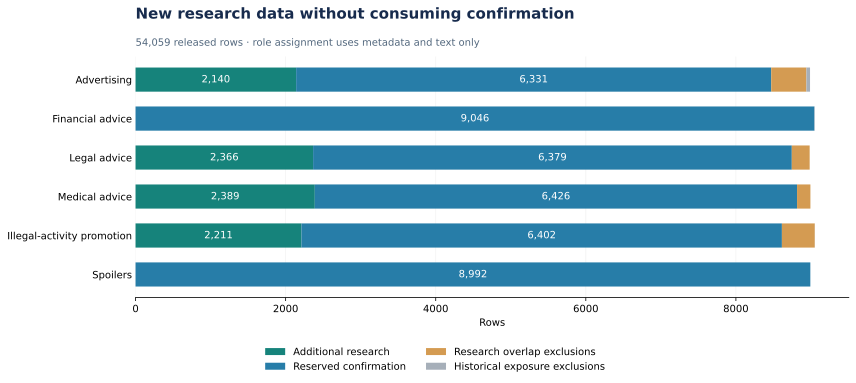

boundary_overlap       1323
confirmation          43576
historical_overlap       54
research               9106
Name: Released rows, dtype: int64

,rule_id,rule_violation,rows
0,advertising,0,1250
1,advertising,1,890
2,legal,0,938
3,legal,1,1428
4,medical,0,1653
5,medical,1,736
6,promotion,0,124
7,promotion,1,2087


Confirmation targets exposed: False
Protocol commit: 9b4d66448998da818b71e4e697aa8e937c9222f0


In [12]:
display_boundary(root)
display(pd.Series(released["boundary"]["role_counts"], name="Released rows"))
display(pd.DataFrame(released["boundary"]["research_label_counts"]))
print("Confirmation targets exposed:", released["boundary"]["confirmation_targets_accessed"])
print("Protocol commit:", released["boundary"]["protocol_commit"])

## 12 · The next deliverable
Run the strongest existing feature families and their controls on frozen four-policy development folds, then freeze one representation for confirmation. Preserve the two reserved policy types and former Private partition until that decision is committed. After successful confirmation, connect the accepted representation to offline inference, complete probability-quality and deployment-budget checks, and publish a concise demonstration and model card. [Exact boundary and next-study requirements](../docs/RELEASED_DATA.md) · [Milestones and acceptance gates](../docs/ROADMAP.md).

In [13]:
display(pd.DataFrame(gate["criteria"]))
print("Final training justified:", gate["final_training_authorized_by_evidence"])
print(gate["decision"])

,requirement,state
0,Broad candidate generation and training-only s...,verified
1,"Matched additions, removals, permutation and s...",verified
2,Unscreened controls and support-geometry alter...,verified
3,Joint comment-rule and support entailment repr...,verified
4,Self-support and approximate-copy stress tests,verified
5,Fixed instruction-likelihood and context ablat...,verified
6,Independent confirmation after feature-family ...,not established
7,Representative coverage of unseen policy types,not established
8,Selected final representation and probability-...,not established
9,Research candidate promoted into offline infer...,blocked until prior requirements pass


Final training justified: False
Retain the reproducible lexical reference. Candidate OOF comparisons are exploratory; repeated selection on two policies is not independent confirmation. The released-data boundary enables a new four-policy research round while reserving financial advice, spoilers and the former private split. Data preparation is not performance confirmation. Feature count and successful execution do not close this gate.


## Reproduce or inspect
The default notebook reads evidence only. The tested commands `jigsaw research --export`, `jigsaw diagnostics`, `jigsaw robustness`, `jigsaw pairs` and `jigsaw instructions` reproduce the separate studies after restoring private artifacts. Completed folds and encoding batches resume; changed dependencies or source create distinct identities. [VALIDATION.md](../docs/VALIDATION.md) records executed checks, cloud lineage and limits.

Continue to [03 · Results and decision](03_saved_results.ipynb).